In [1]:
from sbi_particle_physics.managers.backup import Backup
from sbi_particle_physics.config import DATA_DIR, ACCEPTANCE_COEFFS_PATH, C9, DEFAULT_STRIDE, DEFAULT_PRE_N, DEFAULT_PRERUNS, REAL_DATA
from sbi_particle_physics.objects.model import Model
from sbi_particle_physics.managers.imperfections_diagnostics import ImperfectionsDiagnostics
from sbi_particle_physics.managers.model_diagnostics import ModelDiagnostics
from sbi_particle_physics.managers.real_data import RealData
import torch

In [2]:
device = "cpu" # this small test works on cpu
max_files = 3000
n_points = 100
files = Backup.detect_files(DATA_DIR / "data_6")
print(f"#files found {len(files)}")
files = files[:max_files]
raw_data, raw_parameters, _ = Backup.load_data(files, device)
print(raw_data.shape)

#files found 3


Loading files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading a file
Loading a file
Loading a file
torch.Size([3, 100, 5])


In [3]:
real_raw_data = RealData.load_n_points(REAL_DATA, n_points=n_points, device=device)
print(real_raw_data[:,:].mean(dim=0))
print(real_raw_data[:,-1].mean())

Loading LHCb data (partial):   0%|          | 0/40 [00:00<?, ?it/s]

tensor([ 3.4482,  0.0685, -0.1043, -0.0056,  5.2924])
tensor(5.2924)


In [4]:
def select_closest_c9_dataset(raw_data, c9_values, C9_true):
    distances = torch.abs(c9_values - C9_true)
    idx = torch.argmin(distances).item()
    x_sim_selected = raw_data[idx]
    print(f"Selected C9 = {c9_values[idx].item():.4f} (need to be close to {C9})")
    return x_sim_selected

In [5]:
x_real = real_raw_data # Observed real
x_sim = select_closest_c9_dataset(raw_data, raw_parameters, C9) # "Full" (ie include imperfections)
x_obs = raw_data[1] # Observed but simulated
x_sim_long = raw_data[2:]

Selected C9 = 3.7605 (need to be close to 3.5699999999999994)


In [6]:
def apply_mask(x, q2_max=6.0, mB_max=5.4):
    mask = (x[:, 0] <= q2_max) & (x[:, -1] <= mB_max)
    return x[mask]

x_real = apply_mask(x_real)
x_sim = apply_mask(x_sim)
x_obs = apply_mask(x_obs)
print(f"shape x _long before masking: {x_sim_long.shape}")
x_sim_long = [apply_mask(x) for x in x_sim_long]
print(f"shape x _long after masking: {[x.shape for x in x_sim_long]}")

print(x_real.shape, x_sim.shape, x_obs.shape)

shape x _long before masking: torch.Size([1, 100, 5])
shape x _long after masking: [torch.Size([96, 5])]
torch.Size([93, 5]) torch.Size([96, 5]) torch.Size([93, 5])


In [7]:
def mask_columns_with_zero(x, columns_to_keep):
    y = torch.zeros_like(x)
    y[:, columns_to_keep] = x[:, columns_to_keep]
    return y

cols_to_keep = [0,1,2,3,4] # 1 ok

x_real = mask_columns_with_zero(x_real, cols_to_keep)
x_sim = mask_columns_with_zero(x_sim, cols_to_keep)
x_obs = mask_columns_with_zero(x_obs, cols_to_keep)
x_sim_long = [mask_columns_with_zero(x, cols_to_keep) for x in x_sim_long]

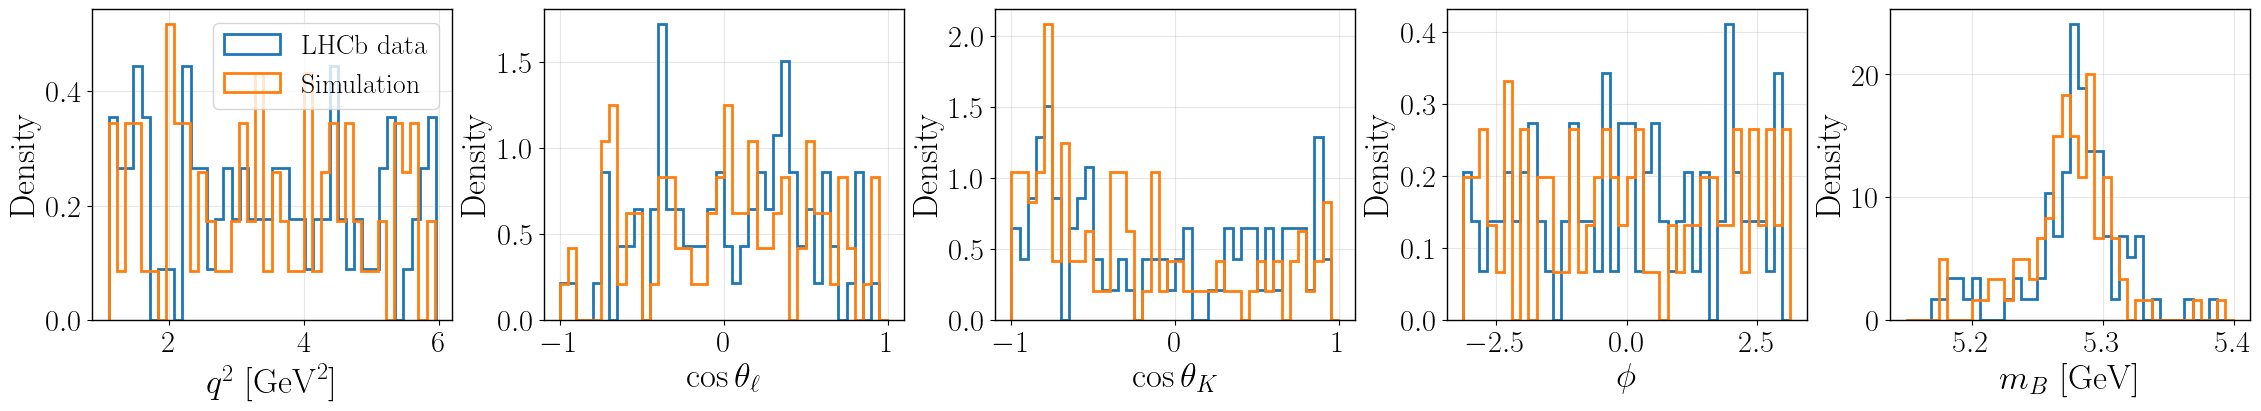

In [8]:
ImperfectionsDiagnostics.compare_real_vs_simulated(x_real, x_sim, bins=40)

In [9]:
ImperfectionsDiagnostics.chi2_test(x_sim, x_real, bins=40)

$q^2\ [\mathrm{GeV}^2]$ : chi2/ndof = 38.05/39, p = 0.513
$\cos\theta_\ell$ : chi2/ndof = 34.36/39, p = 0.681
$\cos\theta_K$ : chi2/ndof = 34.22/39, p = 0.687
$\phi$ : chi2/ndof = 35.77/39, p = 0.618
$m_B\ [\mathrm{GeV}]$ : chi2/ndof = 35.48/39, p = 0.631


In [10]:
ModelDiagnostics.misspecification_test(x_sim_long, x_o=x_real) # <----

/home/hep/nrc25/sbi-particle-physics/src/sbi_particle_physics/managers/model_diagnostics.py:218: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at ../aten/src/ATen/native/ReduceOps.cpp:1823.)
  std = summaries.std(dim=0, keepdim=True).clamp_min(1e-8)


ValueError: batch_size should be a positive integer value, but got batch_size=0

In [ ]:
ModelDiagnostics.misspecification_test_mmd(x_sim_long, x_o=x_real)
# only needs to be between 0.2->0.8 (model is wrong if <0.05)

In [ ]:
ImperfectionsDiagnostics.chi2_test(x_sim, x_obs, bins=40)

In [ ]:
ModelDiagnostics.misspecification_test(x_sim_long, x_o=x_obs) # <----

In [ ]:
ModelDiagnostics.misspecification_test_mmd(x_sim_long, x_o=x_obs)
# only needs to be between 0.2->0.8 (model is wrong if <0.05)